# Linear Regression

1. What is Machine Learning?
2. Types of Machine Learning
3. What is Regression?
4. What is Linear Regression?
5. Real World Examples
6. Types of Linear Regression
7. Assumptions of Linear Regression
8. Mathematical Intuition
9. Cost Function
10. Gradient Descent (Concept)
11. Evaluation Metrics
12. Scikit-Learn Implementation
13. Visualization
14. Interpretation
15. Advantages
16. Disadvantages
16. Interview Questions
17. Mini Project

Machine Learning is a branch of Artificial Intelligence where computers learn patterns from historical data and use those patterns to make predictions or decisions without being explicitly programmed.

1. Supervised Learning
2. Unsupervised Learning
3. Reinforcement Learning

Regression is used when the target variable is continuous.

Examples

House Price
Salary
Temperature
Sales
Revenue
Stock Price

Linear Regression finds the best straight line that describes the relationship between the input variables and the output variable.

Experience → Salary

1 year → ₹30000

2 years → ₹42000

5 years → ₹70000

5. Real World Examples
Predict

House Price

Car Price

Salary

Sales

Profit

Temperature

Electricity Consumption

1. Simple Linear Regression
      One Input

2. Multiple Linear Regression
      Multiple Inputs



   Simple

Salary = f(Experience)

------------------------

Multiple

Salary = f(
Experience,
Age,
Education,
Location
)

1. Linear Relationship

2. No Multicollinearity

3. Homoscedasticity

4. Normal Residuals

5. Independent Errors

The goal is to minimize prediction error.

We use Mean Squared Error (MSE).

Gradient Descent updates the slope and intercept repeatedly until the prediction error becomes as small as possible.

11. Evaluation Metrics
MAE

MSE

RMSE

R² Score

Adjusted R²


12. Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

14. Advantages

Simple

Fast

Easy to Interpret

Works well on linear data

Baseline model

15. Disadvantages


Cannot capture nonlinear relationships

Sensitive to outliers

Needs assumptions

Affected by multicollinearity

# Linear Regression - Energy Efficiency Dataset

## Objective

The objective of this project is to build a Linear Regression model to predict the energy efficiency of buildings based on their physical characteristics.

## Dataset

Dataset: Energy Efficiency Dataset  
Source: UCI Machine Learning Repository

## Target Variables

The dataset contains two target variables:

- Y1 - Heating Load
- Y2 - Cooling Load

For the first Linear Regression model, we will predict **Heating Load**.

In [2]:
# importing dataset from uci ml repositary 
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 

In [3]:
type(X)

pandas.core.frame.DataFrame

In [4]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [5]:
heating_load = y[["Y1"]]

In [6]:
import pandas as pd

In [7]:
energy = pd.concat([X,heating_load], axis=1)
energy.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


In [8]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [9]:
energy.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
dtype: int64

In [10]:
energy.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000


In [11]:
energy

,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84
...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48


In [12]:
y.head()

,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [13]:
energy.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

# 📊 Data Visualization Guide for AI/ML Engineers

## Why Do We Visualize Data?

Before training a Machine Learning model, visualization helps us understand:

- Distribution of data
- Relationships between variables
- Outliers
- Missing-data patterns
- Class imbalance
- Trends over time
- Correlation between features
- Possible nonlinear relationships
- Whether transformations may be required
- Whether a feature could be useful for prediction

The plot we choose depends on the **question we are trying to answer**.

---

# 1. Histogram — Understand Distribution

### Question:
> "How are the values of this numerical feature distributed?"

### Use When:
- Checking numerical feature distributions
- Detecting skewness
- Finding unusual ranges
- Understanding concentration of values
- Checking whether transformation may be useful

### Example Scenarios:

Age distribution of customers

Salary distribution of employees

House-price distribution

Heating-load distribution

Transaction-amount distribution

### Example:

sns.histplot(data=df, x="salary", kde=True)

### Interpretation:

Symmetric → values distributed relatively evenly around center

Right-skewed → long tail toward larger values

Left-skewed → long tail toward smaller values

Multiple peaks → possible subgroups in the data

---

# 2. Box Plot — Detect Potential Outliers and Compare Spread

### Question:
> "Are there unusual values and how spread out is the data?"

### Use When:
- Detecting potential outliers
- Comparing distributions
- Checking median
- Checking spread
- Comparing numerical values across categories

### Example Scenarios:

Employee salaries

House prices

Transaction amounts

Sensor measurements

Delivery times

### Example:

sns.boxplot(data=df, x="salary")

### Important:

A point outside the whiskers is a **potential outlier**, not automatically bad data.

Always investigate before removing it.

---

# 3. Count Plot — Count Categories

### Question:
> "How many observations belong to each category?"

### Use When:
- Checking categorical variables
- Checking class distribution
- Detecting class imbalance
- Understanding category frequencies

### Example Scenarios:

Spam vs Not Spam

Fraud vs Legitimate

Male vs Female

Customer churn Yes/No

Product categories

### Example:

sns.countplot(data=df, x="target")

### ML Importance:

If:

Fraud = 500

Normal = 50,000

the dataset is highly imbalanced.

Accuracy alone may then be misleading.

---

# 4. Bar Plot — Compare Aggregated Values Between Categories

### Question:
> "How does a numerical measurement compare across categories?"

### Use When:
- Comparing average values
- Comparing totals
- Comparing category-level statistics

### Example Scenarios:

Average salary by department

Average sales by region

Average house price by city

Average delivery time by shipping mode

### Example:

sns.barplot(
    data=df,
    x="department",
    y="salary"
)

### Important:

Count Plot → counts rows

Bar Plot → summarizes a numerical variable by category

Do not confuse them.

---

# 5. Scatter Plot — Relationship Between Two Numerical Variables

### Question:
> "Does X appear to have a relationship with Y?"

### Use When:
- Regression problems
- Feature vs target analysis
- Detecting linear relationships
- Detecting nonlinear relationships
- Finding clusters
- Finding unusual observations

### Example Scenarios:

Experience vs Salary

Area vs House Price

Temperature vs Electricity Consumption

Advertising Spend vs Sales

Relative Compactness vs Heating Load

### Example:

sns.scatterplot(
    data=df,
    x="experience",
    y="salary"
)

### Interpretation:

Upward pattern → positive relationship

Downward pattern → negative relationship

Random cloud → weak/no obvious relationship

Curved pattern → possible nonlinear relationship

---

# 6. Line Plot — Changes Over Time

### Question:
> "How does this variable change over time?"

### Use When:
- Time-series data
- Trends
- Sensor readings
- Stock prices
- Website traffic
- Sales over time
- Model training history

### Example Scenarios:

Monthly revenue

Daily temperature

Hourly CPU usage

Daily website visitors

Training loss across epochs

### Example:

sns.lineplot(
    data=df,
    x="date",
    y="sales"
)

### Important:

Line plots are especially useful when observations have a meaningful order,
usually time.

---

# 7. Heatmap — Correlation and Matrix Visualization

### Question:
> "Which numerical variables move together?"

### Use When:
- Feature selection exploration
- Finding highly correlated features
- Detecting possible multicollinearity
- Understanding feature-target relationships
- Visualizing confusion matrices

### Example:

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

### Correlation:

+1 → strong positive linear relationship

 0 → little/no linear relationship

-1 → strong negative linear relationship

### Important:

Correlation does NOT prove causation.

A low Pearson correlation also does not necessarily mean a feature is useless.
The relationship could be nonlinear.

---

# 8. Pair Plot — Explore Many Numerical Relationships

### Question:
> "How are several numerical variables related to each other?"

### Use When:
- Dataset is relatively small
- Number of features is manageable
- Initial EDA
- Finding relationships
- Finding clusters
- Comparing classes

### Example:

sns.pairplot(df)

### Classification Example:

sns.pairplot(
    df,
    hue="target"
)

### Avoid When:

You have hundreds of columns.

You have millions of rows.

The plot becomes too large and difficult to interpret.

---

# 9. KDE Plot — Smooth Distribution

### Question:
> "What is the approximate shape of this distribution?"

### Use When:
- Comparing distributions
- Understanding density
- Comparing classes or groups

### Example:

sns.kdeplot(
    data=df,
    x="salary",
    hue="department"
)

### Difference:

Histogram → actual observations grouped into bins

KDE → smoothed estimate of the distribution

---

# 10. Violin Plot — Distribution + Category Comparison

### Question:
> "How does the full distribution differ between categories?"

### Use When:
- Comparing distributions between groups
- Looking at density and spread together
- Box plots hide too much distribution detail

### Example:

sns.violinplot(
    data=df,
    x="department",
    y="salary"
)

Useful for:

Salary by department

Scores by class

Delivery time by shipping method

---

# 11. Regression Plot — Relationship + Regression Line

### Question:
> "Does a linear model appear reasonable for these two variables?"

### Use When:
- Linear Regression
- Checking linear relationships
- Visualizing a fitted trend

### Example:

sns.regplot(
    data=df,
    x="experience",
    y="salary"
)

The scatter points show the observations.

The line shows the estimated linear trend.

---

# 12. Residual Plot — Diagnose Regression Models

### Question:
> "Is my regression model making errors systematically?"

### Use After:
Training a regression model.

### Example:

sns.residplot(
    x=y_pred,
    y=y_test - y_pred
)

### Desired Pattern:

Residuals randomly scattered around 0.

### Warning Patterns:

Curved pattern → model may be missing nonlinearity

Funnel shape → possible heteroscedasticity

Large isolated points → possible influential observations/outliers

---

# 13. Confusion Matrix Heatmap — Classification Evaluation

### Question:
> "What kinds of classification mistakes is my model making?"

Used for:

Logistic Regression

Decision Trees

Random Forest

SVM

KNN

Naive Bayes

Neural-network classifiers

### Shows:

True Positive

True Negative

False Positive

False Negative

### Example:

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d"
)

---

# 14. ROC Curve — Classification Threshold Performance

### Question:
> "How does the classifier behave across different thresholds?"

### Use When:
- Binary classification
- Comparing classifiers
- Studying sensitivity vs false-positive rate

Common metric:

AUC

Higher AUC generally indicates better ranking ability.

However, ROC-AUC should not be the only metric considered.

---

# 15. Precision-Recall Curve — Imbalanced Classification

### Question:
> "How does precision change when I try to capture more positive cases?"

Especially useful for:

Fraud detection

Spam detection

Disease screening

Rare-event detection

Cybersecurity alerts

### Why?

When positive cases are rare, Precision-Recall analysis can be more informative
than accuracy and sometimes more informative than ROC curves.

---

# 16. Missing-Value Visualization — Data Quality

### Question:
> "Where is data missing?"

### Simple approach:

sns.heatmap(df.isnull(), cbar=False)

Useful when:

A dataset contains many missing values and we want to see whether missingness
appears concentrated in certain rows or columns.

---

# 🧠 QUICK DECISION GUIDE

| Situation | Recommended Plot |
|---|---|
| Numerical distribution | Histogram |
| Potential outliers | Box Plot |
| Category frequency | Count Plot |
| Numerical value across categories | Bar Plot |
| Two numerical variables | Scatter Plot |
| Trend over time | Line Plot |
| Correlation | Heatmap |
| Many numerical relationships | Pair Plot |
| Smooth distribution | KDE Plot |
| Distribution across categories | Violin Plot |
| Linear trend | Regression Plot |
| Regression errors | Residual Plot |
| Classification mistakes | Confusion Matrix |
| Binary classifier thresholds | ROC Curve |
| Imbalanced classification | Precision-Recall Curve |
| Missing-data pattern | Missing-value Heatmap |

---

# 🎯 Think Like an AI/ML Engineer

Do not ask:

> "Which plot should I use?"

First ask:

> "What am I trying to understand?"

Then choose the plot.

### Distribution?

Histogram / KDE

### Outliers?

Box Plot

### Categories?

Count Plot

### Compare categories?

Bar Plot / Box Plot / Violin Plot

### Relationship between two numbers?

Scatter Plot

### Time?

Line Plot

### Correlation?

Heatmap

### Regression relationship?

Scatter Plot / Regression Plot

### Regression errors?

Residual Plot

### Classification performance?

Confusion Matrix / ROC / Precision-Recall Curve

---

# ⚠️ Common Mistakes

1. Using a bar plot for continuous-variable relationships.

2. Removing every box-plot outlier automatically.

3. Assuming correlation means causation.

4. Assuming low correlation means a feature is useless.

5. Creating pair plots with too many features.

6. Using only accuracy for imbalanced classification.

7. Using line plots when the x-axis has no meaningful order.

8. Looking only at training performance.

9. Making plots without asking a specific analytical question.

10. Using visualizations only because they look attractive.

---

# Golden Rule

**Every visualization should answer a question.**

Before creating a plot, ask:

1. What type of variable do I have?
2. What question am I trying to answer?
3. Which visualization answers that question most clearly?
4. What does the result mean for my ML model?

# EDA Exploratory Data Analysis

In [14]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


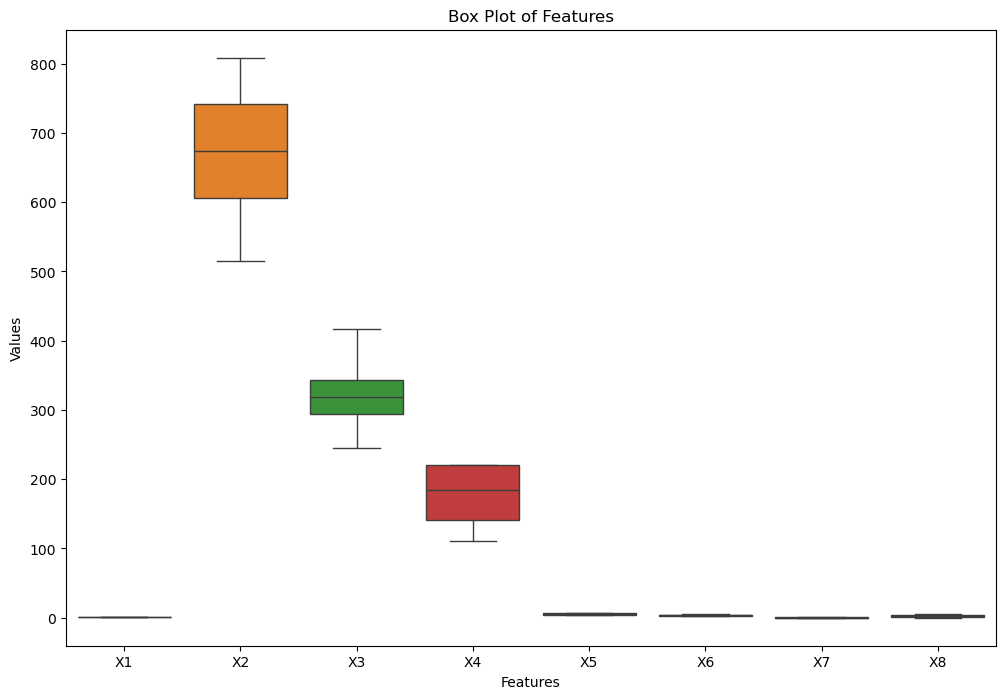

In [37]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=X)

plt.title("Box Plot of Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

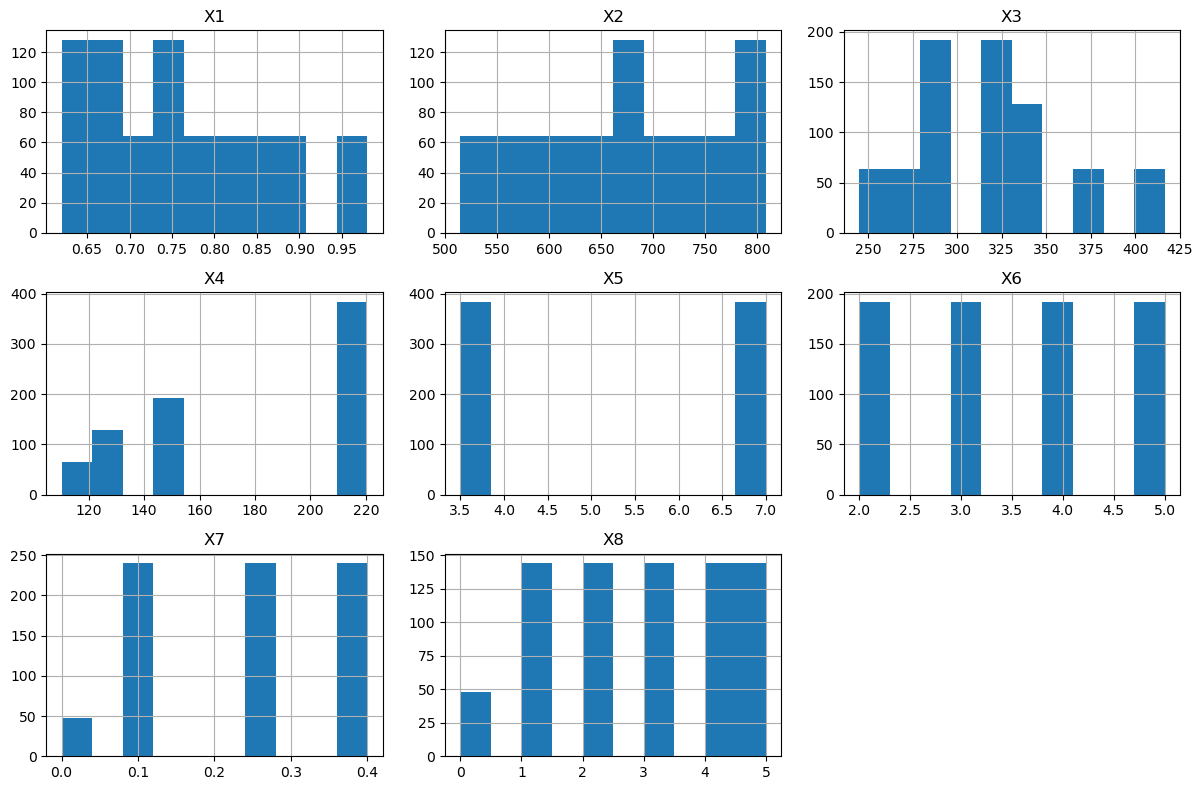

In [15]:
X.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [16]:
import seaborn as sns
import matplotlib.pyplot as  plt 

## 6. Correlation Analysis

Correlation measures the strength and direction of the linear relationship
between numerical variables.

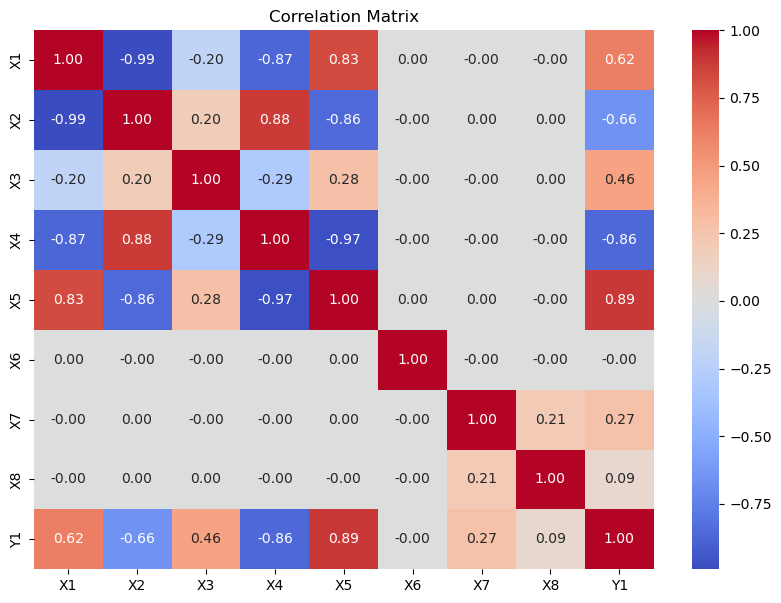

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    energy.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [18]:
print(energy.columns.tolist())

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1']


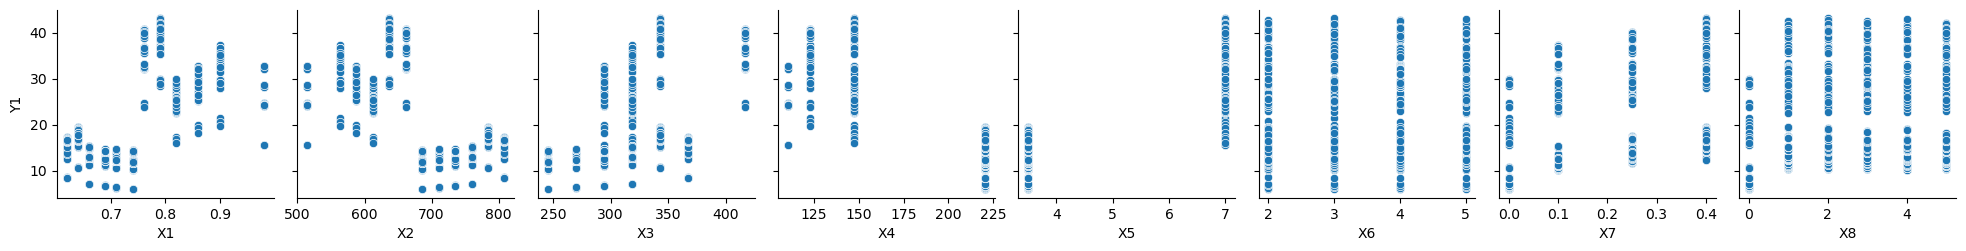

In [19]:
sns.pairplot(
    energy,
    x_vars=["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"],
    y_vars=["Y1"]
)

plt.show()

In [20]:
energy.corr()["Y1"].sort_values(ascending=False)

Y1    1.000000
X5    0.889431
X1    0.622272
X3    0.455671
X7    0.269841
X8    0.087368
X6   -0.002587
X2   -0.658120
X4   -0.861828
Name: Y1, dtype: float64

# Exploratory Data Analysis Report

## Dataset Overview

The Energy Efficiency dataset contains information about different building designs and their energy requirements.

The dataset contains:

- **768 observations**
- **8 input features**
- **2 original target variables**
- **Y1:** Heating Load
- **Y2:** Cooling Load

For this Linear Regression analysis, **Y1 (Heating Load)** is selected as the target variable.

---

## Feature Description

| Feature | Description |
|---------|-------------|
| X1 | Relative Compactness |
| X2 | Surface Area |
| X3 | Wall Area |
| X4 | Roof Area |
| X5 | Overall Height |
| X6 | Orientation |
| X7 | Glazing Area |
| X8 | Glazing Area Distribution |
| Y1 | Heating Load |

---

## Data Quality

The dataset was inspected for:

- Missing values
- Duplicate records
- Incorrect data types
- Unusual values

The dataset does not contain missing values in the original UCI data.

All input features are numerical, which makes the dataset suitable for regression analysis.

Some observations may have identical feature combinations or repeated design characteristics, so duplicate handling should be based on whether the complete records are truly redundant rather than removing them automatically.

---

## Univariate Analysis

The distributions of individual features were examined using histograms and box plots.

Several variables contain a limited number of unique values because they represent predefined building design configurations rather than completely continuous measurements.

For example:

- Orientation represents different building orientations.
- Overall Height contains specific building-height configurations.
- Glazing Area contains predefined glazing levels.
- Glazing Area Distribution represents different glazing arrangements.

Therefore, unusual-looking distributions in these variables are not necessarily data-quality problems.

---

## Target Variable Analysis

The target variable **Y1 represents Heating Load**.

Heating Load varies considerably across different building designs, indicating that building characteristics have an important effect on energy requirements.

The variation in Y1 makes it suitable as a continuous target variable for a regression problem.

---

## Bivariate Analysis

Scatter plots were used to examine the relationship between each input feature and Heating Load.

Some features show clear relationships with Heating Load, while others show weaker patterns.

Features related to the physical size and structure of the building show noticeable relationships with Heating Load.

Relative Compactness, Surface Area, Roof Area, Overall Height, and Glazing Area appear particularly useful for explaining differences in heating requirements.

Orientation and Glazing Area Distribution show weaker simple linear relationships with Heating Load.

---

## Correlation Analysis

A correlation matrix was used to examine linear relationships between the numerical variables.

The analysis indicates that several building characteristics are associated with Heating Load.

Important relationships are observed for features such as:

- Relative Compactness
- Surface Area
- Roof Area
- Overall Height
- Glazing Area

Orientation and Glazing Area Distribution have comparatively weak linear correlations with Heating Load.

Strong correlations also exist between some input features themselves.

For example, building geometry variables such as Relative Compactness, Surface Area, Roof Area, and Overall Height are related to one another.

This indicates the possible presence of **multicollinearity**.

Multicollinearity does not necessarily prevent Linear Regression from making predictions, but it can make individual regression coefficients harder to interpret reliably.

---

## Outlier Analysis

Box plots may identify some observations as potential outliers.

However, these observations should not automatically be removed.

The Energy Efficiency dataset was generated from different valid building configurations, so extreme values may represent legitimate building designs rather than incorrect data.

Outliers should therefore be investigated before deciding whether they should be removed.

---

## Key Findings

1. The dataset contains 768 building observations and 8 input features.

2. Heating Load (Y1) is a continuous numerical variable and is suitable for a regression problem.

3. The original dataset does not contain missing values.

4. Several building geometry features show meaningful relationships with Heating Load.

5. Relative Compactness, Surface Area, Roof Area, Overall Height, and Glazing Area appear particularly relevant to Heating Load.

6. Orientation and Glazing Area Distribution show weaker simple linear relationships with the target.

7. Some input variables are strongly correlated with each other, indicating potential multicollinearity.

8. Some variables are discrete design parameters even though they are represented numerically.

9. Potential outliers should not be removed without first determining whether they represent valid building configurations.

---

## Conclusion

The Exploratory Data Analysis shows that the Energy Efficiency dataset is suitable for building a regression model to predict Heating Load.

Several building characteristics have clear relationships with the target variable, while some features have weaker individual relationships.

The presence of correlations between input features should be considered when interpreting the Linear Regression model.

The next step is to prepare the feature matrix and target variable, split the dataset into training and testing sets, train a Linear Regression model, and evaluate its performance using regression metrics such as MAE, MSE, RMSE, and R².

In [21]:
## features and target 
predictive_coloumn = ["X2","X4","X5"]
target_column = "Y1" # heating load 

<Axes: >

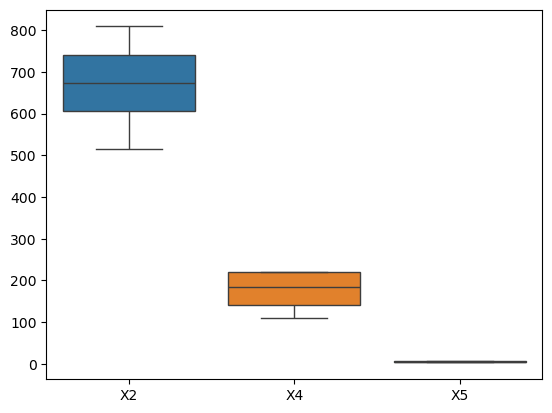

In [22]:

sns.boxplot(energy[predictive_coloumn])


In [23]:
from sklearn.preprocessing import StandardScaler


In [24]:
scaler = StandardScaler()

In [25]:
features = energy[predictive_coloumn]

In [26]:
features_scaled = scaler.fit_transform(features)

In [27]:
features_scaled.std(axis=0) #standard deviation 

array([1., 1., 1.])

In [28]:
features_scaled.mean(axis=0) # average 

array([-4.16333634e-16,  2.17418676e-16,  0.00000000e+00])

In [29]:
features_scaled[:,1] # first column 

array([-1.47007664, -1.47007664, -1.47007664, -1.47007664, -1.19867787,
       -1.19867787, -1.19867787, -1.19867787, -0.65588035, -0.65588035,
       -0.65588035, -0.65588035, -0.65588035, -0.65588035, -0.65588035,
       -0.65588035, -0.65588035, -0.65588035, -0.65588035, -0.65588035,
       -1.19867787, -1.19867787, -1.19867787, -1.19867787,  0.97251224,
        0.97251224,  0.97251224,  0.97251224,  0.97251224,  0.97251224,
        0.97251224,  0.97251224,  0.97251224,  0.97251224,  0.97251224,
        0.97251224,  0.97251224,  0.97251224,  0.97251224,  0.97251224,
        0.97251224,  0.97251224,  0.97251224,  0.97251224,  0.97251224,
        0.97251224,  0.97251224,  0.97251224, -1.47007664, -1.47007664,
       -1.47007664, -1.47007664, -1.19867787, -1.19867787, -1.19867787,
       -1.19867787, -0.65588035, -0.65588035, -0.65588035, -0.65588035,
       -0.65588035, -0.65588035, -0.65588035, -0.65588035, -0.65588035,
       -0.65588035, -0.65588035, -0.65588035, -1.19867787, -1.19

In [39]:
features_scaled[:,0].mean() # first column 

-4.163336342344337e-16

In [31]:
# fit transform outputs numpy array

## Train-Test Split

The dataset is divided into training and testing sets.

- **Training data:** Used to train the model.
- **Testing data:** Used to evaluate the model on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

In [44]:
features_scaled

array([[-1.78587489, -1.47007664,  1.        ],
       [-1.78587489, -1.47007664,  1.        ],
       [-1.78587489, -1.47007664,  1.        ],
       ...,
       [ 1.55394308,  0.97251224, -1.        ],
       [ 1.55394308,  0.97251224, -1.        ],
       [ 1.55394308,  0.97251224, -1.        ]])

In [46]:
target = energy[target_column]
target

0      15.55
1      15.55
2      15.55
3      15.55
4      20.84
       ...  
763    17.88
764    16.54
765    16.44
766    16.48
767    16.64
Name: Y1, Length: 768, dtype: float64

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    target,
    test_size=0.2,
    random_state=42
)

In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 3)
(154, 3)
(614,)
(154,)


## Model Training

A Linear Regression model is created and trained using the training dataset.

The model learns the relationship between the selected input features
(X2, X4, X5) and the target variable Y1 (Heating Load).

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()

In [51]:
model.fit(X_train, y_train)

LinearRegression()

In [53]:
#The model learns a coefficient for each feature plus an intercept:
"""Heating Load =
    intercept
    + coefficient₁ × X2
    + coefficient₂ × X4
    + coefficient₃ × X5 """

model.coef_

array([ 4.48272396, -3.41718539,  9.48646446])

In [54]:
model.intercept_

22.269724962226384

In [55]:
y_train_pred = model.predict(X_train)
y_train_pred

array([30.98236403, 15.17828028, 29.73474053, 30.34195681, 13.93065678,
       30.34195681, 30.34195681, 32.22998753, 16.42590378, 15.17828028,
       15.17828028, 15.17828028, 30.98236403, 35.33245082, 35.33245082,
       12.68303327, 16.42590378, 35.33245082, 10.18778627, 28.77412969,
       16.42590378, 32.22998753, 13.93065678, 10.18778627, 35.33245082,
       35.33245082, 11.43540977, 12.68303327, 30.34195681, 10.18778627,
       30.34195681, 15.17828028, 28.77412969, 10.18778627, 11.43540977,
       32.22998753, 30.34195681, 13.93065678, 35.33245082, 10.18778627,
       32.22998753, 32.22998753, 28.77412969, 12.68303327, 28.77412969,
       13.93065678, 11.43540977, 30.34195681, 16.42590378, 29.73474053,
       15.17828028, 30.98236403, 30.98236403, 28.77412969, 29.73474053,
       12.68303327, 30.98236403, 13.93065678, 16.42590378, 28.77412969,
       10.18778627, 12.68303327, 30.34195681, 29.73474053, 30.98236403,
       13.93065678, 30.98236403, 12.68303327, 28.77412969, 32.22

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [60]:
import numpy as np
train_mse = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_true=y_train, y_pred=y_train_pred)
train_r2 = r2_score(y_true=y_train, y_pred=y_train_pred)

In [62]:
print("train preformance ")
print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train MAE :", train_mae)
print("Train R²  :", train_r2)

train preformance 
Train MSE : 16.654490114259357
Train RMSE: 4.080991315141378
Train MAE : 3.0707870853052
Train R²  : 0.8349797413172049


In [63]:
target.max()

43.1

In [65]:
#test data prediction 
y_test_pred = model.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [67]:
print("Test Performance")

print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)
print("Test R²   :", test_r2)

Test Performance
Test MSE  : 15.740471592365084
Test RMSE : 3.9674263184544567
Test MAE  : 2.9700504633557596
Test R²   : 0.848985536247928


## Model Evaluation

The Linear Regression model was evaluated using MAE, MSE, RMSE, and R².

### Training Performance

- MSE: 16.65
- RMSE: 4.08
- MAE: 3.07
- R²: 0.835

### Testing Performance

- MSE: 15.74
- RMSE: 3.97
- MAE: 2.97
- R²: 0.849

### Interpretation

The model achieved an R² score of approximately 0.85 on the test dataset,
indicating that approximately 85% of the variation in Heating Load is explained
by the selected features.

The training and testing scores are very similar, which suggests that the model
generalizes well to unseen data and shows no obvious sign of overfitting.

The test MAE of approximately 2.97 indicates that the model's predictions differ
from the actual Heating Load by about 2.97 units on average.

The RMSE is higher than the MAE, indicating that some observations have larger
prediction errors.

Overall, the Linear Regression model provides a useful baseline for predicting
Heating Load using the selected features X2, X4, and X5.

## Residual Analysis

Residuals represent the difference between the actual and predicted values.

Residual analysis is performed to determine whether the Linear Regression
model is making systematic prediction errors.

A good Linear Regression model should generally have residuals randomly
distributed around zero without a strong visible pattern.

The residual distribution is also examined to identify skewness,
extreme prediction errors, and possible violations of regression assumptions.

In [68]:
residuals = y_test - y_test_pred

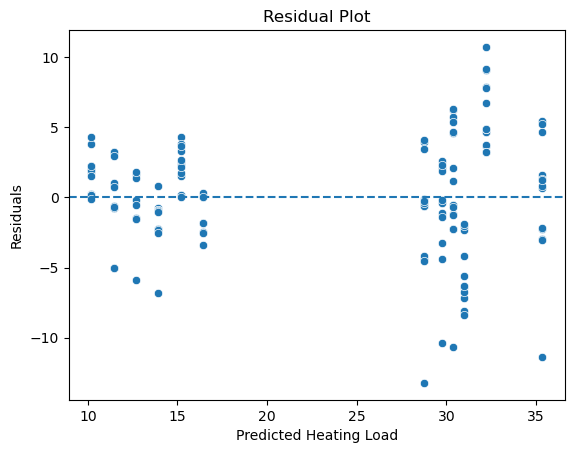

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=y_test_pred, y=residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Heating Load")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

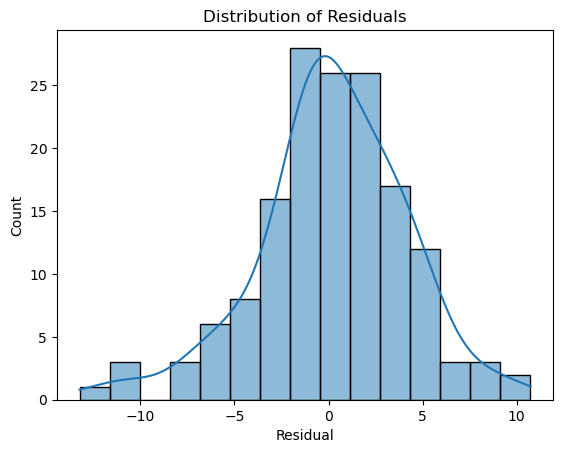

In [70]:
sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()